In [1]:
%load_ext autoreload
%autoreload 2

import os, random, copy
import numpy as np
import torch

from gllvm.simulations import make_sparse, simulate
from gllvm.encoder import Encoder
from gllvm.fitter import VAEFitter, ZQEFitter
from gllvm.plots import compare_wz, compare_bias, compare_z
from gllvm.glms import PoissonLog1pGLM          # T(y) = log(1+y) ZQE variant

# ------------------------------------------------------------------ seeds
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [2]:

# ── VAE vs MAP vs Gaussian-posterior vs Sim-trained encoder ──────────────────
from IPython.display import clear_output; clear_output(wait=True)
import copy, torch, numpy as np
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from torch.optim.swa_utils import AveragedModel
from gllvm.encoder import GaussianPosteriorEncoderLog1p, MapEncoderGaussianLog1p
from gllvm.simulations import make_sparse, simulate, make_mixed
from gllvm.encoder import Encoder
from gllvm.fitter import VAEFitter
from gllvm.glms import PoissonLog1pGLM, PoissonGLM
from gllvm.gllvm_module import GLMFamily

torch.manual_seed(1234)

NL, ACT, NR, NS = 2, 2, 10, 200
WZS = 1.
RPL = NR // 2
DEV = "cuda" if torch.cuda.is_available() else "cpu"

g0m = make_sparse(n_latent=NL, poisson=NR, active_latent=ACT, wz_scale=WZS,
                  responses_per_latent=RPL).to(DEV)
y_all, z_all = simulate(g0m, n_samples=NS, device=DEV)   # keep true z for Z-pred plot
n_val = int(0.15 * NS)
yt, yv = y_all[n_val:], y_all[:n_val]   # VAE uses train/val split
y_zqe  = y_all                             # ZQE and R gllvm use all samples


def _best_rotation(A, B):
    """Orthogonal Procrustes minimising ||A - B@R||, allowing reflections."""
    U, _, Vt = np.linalg.svd(A.T @ B)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(A - B @ R1) <= np.linalg.norm(A - B @ R2) else R2


def procr(g_true, g_est):
    a = g_true.wz.detach().cpu().numpy()
    b = g_est.wz.detach().cpu().numpy()
    R = _best_rotation(a, b)
    return float(np.linalg.norm(a - b @ R) / np.linalg.norm(a))


_POISSON_NAMES = {
    "PoissonGLM", "PoissonLog1pGLM", "PoissonSqrtGLM",
    "PoissonLog1pSqrtGLM", "PoissonMixedTGLM", "PoissonMultiTGLM",
}


def fresh_decoder(glm_cls):
    g = copy.deepcopy(g_vae_m)
    g.families = [
        GLMFamily(glm_cls, fam.idx, fam.params, fam.name)
        if fam.GLM.__name__ in _POISSON_NAMES else fam
        for fam in g.families
    ]
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g


class Log1pEncoder(Encoder):
    """Encoder with log1p input normalisation."""
    def forward(self, y):
        return super().forward(torch.log1p(y.float()))


class SimTrainedEncoder(nn.Module):
    """Tracking encoder trained online on simulated (y_sim, z_sim) pairs."""
    def __init__(self, input_dim, latent_dim, hidden=64,
                 lr_enc=1e-3, n_sim=512, n_enc_steps=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),    nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.n_sim       = n_sim
        self.n_enc_steps = n_enc_steps
        self._opt = torch.optim.Adam(self.parameters(), lr=lr_enc)

    def forward(self, y):
        return self.mu_head(self.net(y.float()))

    def sample(self, y):
        with torch.no_grad():
            mu = self.forward(y)
        return mu, mu, torch.full_like(mu, float("-inf"))

    def update(self, g):
        for _ in range(self.n_enc_steps):
            with torch.no_grad():
                z_sim = g.sample_z(self.n_sim)
                y_sim = g.sample(z=z_sim)
            mu_pred = self.forward(y_sim)
            loss = ((mu_pred - z_sim) ** 2).mean()
            self._opt.zero_grad(); loss.backward(); self._opt.step()

    def loss(self, y, gllvm=None, **kwargs):
        dummy = next(self.parameters())
        return torch.zeros(1, device=dummy.device, requires_grad=True), 0.0


class PoissonMAPEncoder(nn.Module):
    """Per-observation Poisson MAP encoder via L-BFGS.

    Solves, for each observation y_i (a length-p count vector):

        z* = argmax_z  { sum_j [ y_ij * eta_j(z) - exp(eta_j(z)) ]
                         - 0.5 * ||z||^2 }

    where eta_j(z) = w_j' z + b_j  (canonical Poisson log-link).

    Dimensional mapping from glmfit.ipynb notation:
        glmfit  X[N, P] @ B[P, K]  =  eta[N, K]
        here    W[p, q] @ z.T[q, batch]  =  eta.T[p, batch]
      so  X=W (p×q),  B=z.T (q×batch),  Y=y.T (p×batch),  ridge=1.0

    L-BFGS minimises the negative MAP objective via a deterministic closure.
    Warm start: closed-form Gaussian MAP in log1p-space.
    """
    def __init__(self, g, max_iter: int = 20, history_size: int = 10):
        super().__init__()
        self.g = g
        self._gauss_init = MapEncoderGaussianLog1p(g)
        self.max_iter    = max_iter
        self.history_size = history_size

    def sample(self, y):
        W = self.g.wz.detach()                            # [p, q]
        b = (self.g.bias.detach() if self.g.bias is not None
             else torch.zeros(W.shape[0], device=W.device, dtype=W.dtype))
        y_f = y.float()

        # ── Warm start (no grad needed) ───────────────────────────────────────
        with torch.no_grad():
            z_init, _, _ = self._gauss_init.sample(y)
        # z shape: [batch, q]  — this is what we optimise
        z = nn.Parameter(z_init.detach().clone().to(W.dtype))

        opt = torch.optim.LBFGS([z], max_iter=self.max_iter,
                                 history_size=self.history_size,
                                 line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            # eta[batch, p] = z[batch,q] @ W.T[q,p] + b[p]
            eta = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
            neg_map = (torch.exp(eta) - y_f * eta).sum() + 0.5 * (z ** 2).sum()
            neg_map.backward()
            return neg_map

        opt.step(closure)

        z_out = z.detach()
        return z_out, z_out, torch.full_like(z_out, float("-inf"))

    def loss(self, y, gllvm=None, **kwargs):
        return torch.zeros(1, device=self.g.wz.device, requires_grad=True), 0.0


# ── LR schedule helpers ───────────────────────────────────────────────────────
BATCH_SIZE = 1000


def _flat_rm_scheduler(opt, epochs, flat_frac=0.1, rm_alpha=0.6, rm_a=1.0):
    flat_epochs = int(flat_frac * epochs)
    def lr_lambda(epoch):
        if epoch < flat_epochs:
            return 1.0
        t = epoch - flat_epochs + 1
        return 1.0 / (rm_a + t) ** rm_alpha * rm_a ** rm_alpha
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)


def _flat_cos_scheduler(opt, lr_init, min_lr, epochs, flat_frac=0.5):
    T_flat = int(flat_frac * epochs)
    T_cos  = epochs - T_flat
    base_lr = lr_init
    def lr_lambda(epoch):
        if epoch < T_flat:
            return 1.0
        t = epoch - T_flat
        cos_val = 0.5 * (1.0 + math.cos(math.pi * t / max(T_cos, 1)))
        return (min_lr + (base_lr - min_lr) * cos_val) / base_lr
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)


def run_zqe(g, enc, label, colour,
            lr_init=1e-2, min_lr=1e-5,
            epochs=500, wz_idx=None,
            sched="flat_rm", flat_frac=0.1,
            rm_alpha=0.6, rm_a=1.0,
            factor=0.5,
            ema_decay=0.95, ema_start=20,
            n_mc=4, opt_name="adam"):

    dec_params = list(g.parameters())
    if opt_name == "sgd":
        opt = torch.optim.SGD(dec_params, lr=lr_init)
    else:
        opt = torch.optim.Adam(dec_params, lr=lr_init)

    if sched == "flat_rm":
        scheduler = _flat_rm_scheduler(opt, epochs,
                                       flat_frac=flat_frac,
                                       rm_alpha=rm_alpha, rm_a=rm_a)
        sched_info = f"flat({int(flat_frac*100)}%)+RM alpha={rm_alpha} a={rm_a}"
    else:
        scheduler = _flat_cos_scheduler(opt, lr_init, min_lr, epochs, flat_frac=flat_frac)
        sched_info = f"flat({int(flat_frac*100)}%)+cos→{min_lr:.0e}"

    ema_decay_fn = lambda avg, cur, n: ema_decay * avg + (1 - ema_decay) * cur
    ema_model  = AveragedModel(g, avg_fn=ema_decay_fn)
    ema_active = False

    h_err, h_err_ema, h_loss, h_wz = [], [], [], []
    print(f"\n[{label}]  start Proc={procr(g0m, g):.4f}"
          f"  lr_init={lr_init:.1e}  {sched_info}")

    for ep in range(epochs):
        if hasattr(enc, 'update'):
            enc.update(g)

        ep_loss, n_b = 0.0, 0
        perm = torch.randperm(len(y_zqe), device=DEV)
        for i in range(0, len(y_zqe), BATCH_SIZE):
            batch = y_zqe[perm[i:i+BATCH_SIZE]]
            m1_vals, m2_vals = [], []
            for _ in range(n_mc):
                with torch.no_grad():
                    zq0 = g.sample_z(len(batch)); yq = g.sample(z=zq0)
                    z,  _, _ = enc.sample(batch)
                    zq, _, _ = enc.sample(yq)
                m1_vals.append(g.zq_log(batch, z=z).sum(-1).mean())
                m2_vals.append(g.zq_log(yq,   z=zq).sum(-1).mean())
            m1 = torch.stack(m1_vals).mean()
            m2 = torch.stack(m2_vals).mean()
            loss = -(m1 - m2)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(dec_params, 5.0)
            if not torch.isnan(loss): opt.step()
            ep_loss += loss.item(); n_b += 1

        mean_loss = ep_loss / n_b
        scheduler.step()

        if ep >= ema_start:
            ema_model.update_parameters(g)
            ema_active = True

        h_err.append(procr(g0m, g))
        h_loss.append(mean_loss)
        h_err_ema.append(procr(g0m, ema_model.module) if ema_active else h_err[-1])
        if wz_idx is not None:
            h_wz.append(g.wz.detach().cpu().numpy().ravel()[wz_idx].copy())
        if (ep + 1) % 200 == 0:
            print(f"  ep {ep+1:4d}/{epochs}  loss={mean_loss:+.6f}"
                  f"  Proc={h_err[-1]:.4f}  Proc(EMA)={h_err_ema[-1]:.4f}"
                  f"  lr={opt.param_groups[0]['lr']:.2e}")

    print(f"[{label}]  final  raw={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}")
    return h_err, h_err_ema, h_loss, h_wz



VAE Proc=0.2105

[Gauss MAP (T=log1p)]  start Proc=0.9140  lr_init=5.0e-01  flat(10%)+cos→1e-10
  ep  200/2000  loss=-0.573824  Proc=0.1893  Proc(EMA)=0.1974  lr=5.00e-01
  ep  400/2000  loss=-1.006072  Proc=0.2099  Proc(EMA)=0.1821  lr=4.85e-01
  ep  600/2000  loss=-0.511795  Proc=0.1790  Proc(EMA)=0.1723  lr=4.42e-01
  ep  800/2000  loss=+0.280163  Proc=0.1851  Proc(EMA)=0.1757  lr=3.75e-01
  ep 1000/2000  loss=-0.068747  Proc=0.2245  Proc(EMA)=0.1819  lr=2.93e-01
  ep 1200/2000  loss=+0.110122  Proc=0.1769  Proc(EMA)=0.1831  lr=2.07e-01
  ep 1400/2000  loss=-0.062407  Proc=0.1773  Proc(EMA)=0.1801  lr=1.25e-01
  ep 1600/2000  loss=-0.669332  Proc=0.1838  Proc(EMA)=0.1618  lr=5.85e-02
  ep 1800/2000  loss=-0.346708  Proc=0.1856  Proc(EMA)=0.1812  lr=1.51e-02
  ep 2000/2000  loss=-0.331452  Proc=0.1790  Proc(EMA)=0.1791  lr=1.00e-10
[Gauss MAP (T=log1p)]  final  raw=0.1790  EMA=0.1791

[Gauss posterior (T=log1p)]  start Proc=1.5305  lr_init=5.0e-01  flat(10%)+cos→1e-10
  ep  200/2000 

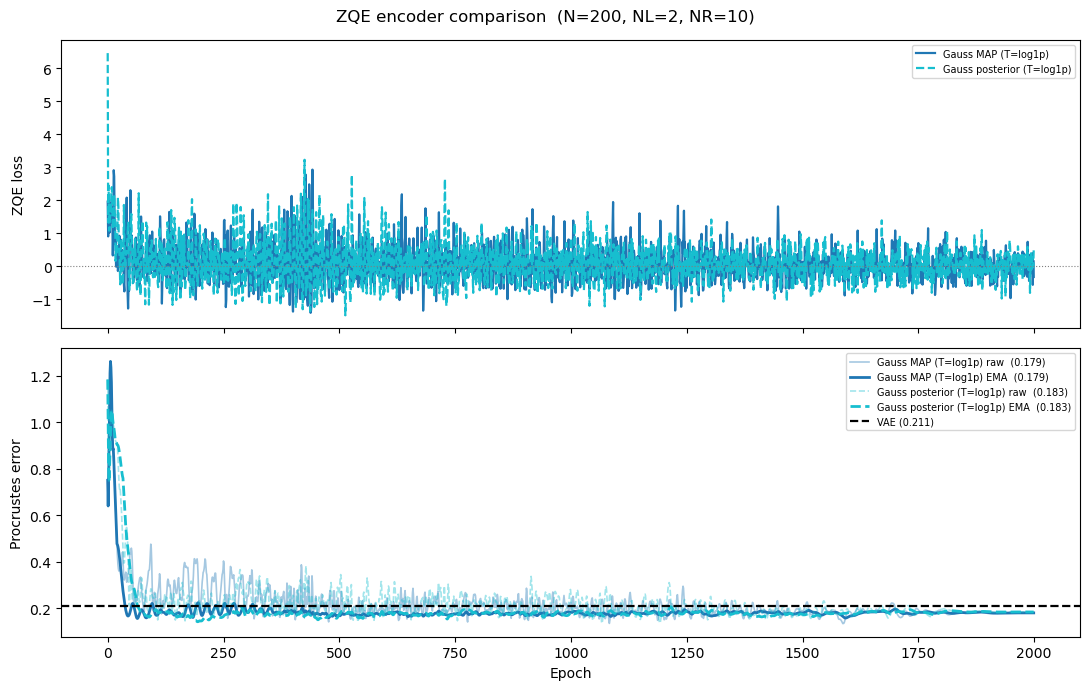


Method                                    raw      EMA
──────────────────────────────────────────────────────
VAE                                    0.2105        —
Gauss MAP (T=log1p)                    0.1790   0.1791
Gauss posterior (T=log1p)              0.1829   0.1830


In [3]:

# ── 1. VAE baseline ──────────────────────────────────────────────────────────
EPOCHS_ZQE = 2000
SMOOTH     = 1
N_WZ_TRACK = 20

VAE_HIDDEN = max(64, min(256, int(NR ** 0.5) * 4))
g_vae_m   = make_mixed(n_latent=NL, poisson=NR, wz_scale=WZS).to(DEV)
enc_vae_m = Log1pEncoder(input_dim=NR, latent_dim=NL, hidden=VAE_HIDDEN).to(DEV)
WARMUP_EP = max(500, NR // 4)
fv = VAEFitter(g_vae_m, enc_vae_m, lr=1e-2, device=DEV)
fv.fit(yt, epochs=WARMUP_EP, batch_size=256, verbose=False)
for lr_stage, patience_stage in [(3e-3, 100), (1e-3, 120), (3e-4, 150), (1e-4, 200)]:
    fitter = VAEFitter(g_vae_m, enc_vae_m, lr=lr_stage, device=DEV)
    best_ve, no_imp, best_wz_v, best_b_v, best_enc_sd = float("-inf"), 0, None, None, None
    for ep in range(3000):
        fitter.fit(yt, epochs=1, batch_size=256, verbose=False)
        with torch.no_grad():
            _, ve = enc_vae_m.loss(yv.to(DEV), g_vae_m)
        if ve > best_ve + 0.05:
            best_ve, no_imp = ve, 0
            best_wz_v = g_vae_m.wz.detach().clone()
            best_b_v  = g_vae_m.bias.detach().clone()
            best_enc_sd = copy.deepcopy(enc_vae_m.state_dict())
        else:
            no_imp += 1
            if no_imp >= patience_stage:
                break
    g_vae_m.wz.data.copy_(best_wz_v); g_vae_m.bias.data.copy_(best_b_v)
    enc_vae_m.load_state_dict(best_enc_sd)
err_vae_m = procr(g0m, g_vae_m)
print(f"VAE Proc={err_vae_m:.4f}")


def make_enc(enc_type, g):
    if enc_type == "map":
        return MapEncoderGaussianLog1p(g)
    elif enc_type == "gp":
        return GaussianPosteriorEncoderLog1p(g, sigma2=1.0)
    elif enc_type == "poisson_map":
        return PoissonMAPEncoder(g, n_newton=20)
    elif enc_type == "sim_trained":
        return SimTrainedEncoder(NR, NL, hidden=VAE_HIDDEN,
                                 lr_enc=1e-3, n_sim=512, n_enc_steps=10)
    else:
        raise ValueError(f"Unknown enc_type: {enc_type}")


# ── 2. ZQE arms ───────────────────────────────────────────────────────────────
_wz_flat = g0m.wz.detach().cpu().numpy().ravel()
wz_idx   = np.random.choice(len(_wz_flat), min(N_WZ_TRACK, len(_wz_flat)), replace=False)
wz_true  = _wz_flat[wz_idx]

ARMS = [
    ("Gauss MAP (T=log1p)",           "tab:blue",   PoissonLog1pGLM, "map",         "flat_cos", {}),
    ("Gauss posterior (T=log1p)",     "tab:cyan",   PoissonLog1pGLM, "gp",          "flat_cos", {}),
    # ("Gauss posterior SGD (T=log1p)", "tab:green",  PoissonLog1pGLM, "gp",          "flat_rm",
    #  {"opt_name": "sgd", "lr_init": 1.0, "flat_frac": 0.2, "rm_alpha": 0.5, "rm_a": 2.0}),
    # ("Sim-tracked Adam (T=clean)",    "tab:orange", PoissonGLM,      "sim_trained", "flat_cos", {}),
    # ("Poisson MAP enc (T=log1p dec)", "tab:purple", PoissonLog1pGLM, "poisson_map", "flat_rm",
    # {"opt_name": "sgd", "lr_init": 1.0, "flat_frac": 0.2, "rm_alpha": 0.5, "rm_a": 2.0}),
    # ("Poisson MAP enc (T=canon)",     "tab:red",    PoissonGLM,      "poisson_map", "flat_cos", {}),
]

results  = {}
encoders = {}   # label -> final encoder (for Z-prediction plot)
for label, colour, glm_cls, enc_type, sched, extra_kw in ARMS:
    try:
        g   = fresh_decoder(glm_cls)
        enc = make_enc(enc_type, g).to(DEV)
        kw  = dict(extra_kw)
        opt_name = kw.pop("opt_name", "adam")
        lr_init  = kw.pop("lr_init",  5e-1)
        min_lr   = kw.pop("min_lr",   1e-10)
        h_err, h_err_ema, h_loss, h_wz = run_zqe(
            g, enc, label, colour,
            lr_init=lr_init, min_lr=min_lr,
            epochs=EPOCHS_ZQE, wz_idx=wz_idx,
            sched=sched, opt_name=opt_name, **kw,
        )
        results[label]  = (h_err, h_err_ema, h_loss, h_wz, colour, enc_type, g)
        encoders[label] = enc
    except Exception as _e:
        print(f"[{label}] FAILED: {_e}")
        import traceback; traceback.print_exc()

# ── Plots ─────────────────────────────────────────────────────────────────────
def smooth(x, w):
    return np.convolve(x, np.ones(w)/w, mode="valid")

xs = np.arange(SMOOTH - 1, EPOCHS_ZQE)

def _ls(lbl):
    if "MAP"       in lbl: return "-"
    if "posterior" in lbl: return "--"
    return "-."

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle(f"ZQE encoder comparison  (N={NS}, NL={NL}, NR={NR})")
for label, (h_err, h_err_ema, h_loss, h_wz, col, enc_type, _g) in results.items():
    ls = _ls(label)
    ax0.plot(xs, smooth(h_loss,    SMOOTH), color=col, lw=1.6, ls=ls, label=label)
    ax1.plot(xs, smooth(h_err,     SMOOTH), color=col, lw=1.2, ls=ls, alpha=0.4,
             label=f"{label} raw  ({h_err[-1]:.3f})")
    ax1.plot(xs, smooth(h_err_ema, SMOOTH), color=col, lw=2.0, ls=ls,
             label=f"{label} EMA  ({h_err_ema[-1]:.3f})")
ax0.axhline(0, color="gray", ls=":", lw=0.8)
ax0.set_ylabel("ZQE loss"); ax0.legend(fontsize=7)

ax1.axhline(err_vae_m, color="black", ls="--", lw=1.6, label=f"VAE ({err_vae_m:.3f})")
ax1.set_ylabel("Procrustes error"); ax1.legend(fontsize=7)
ax1.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

print(f"\n{'Method':<36} {'raw':>8} {'EMA':>8}")
print(f"{'─'*54}")
print(f"{'VAE':<36} {err_vae_m:>8.4f} {'—':>8}")
for label, (h_err, h_err_ema, _, _, _, enc_type, _g) in results.items():
    print(f"{label:<36} {h_err[-1]:>8.4f} {h_err_ema[-1]:>8.4f}")


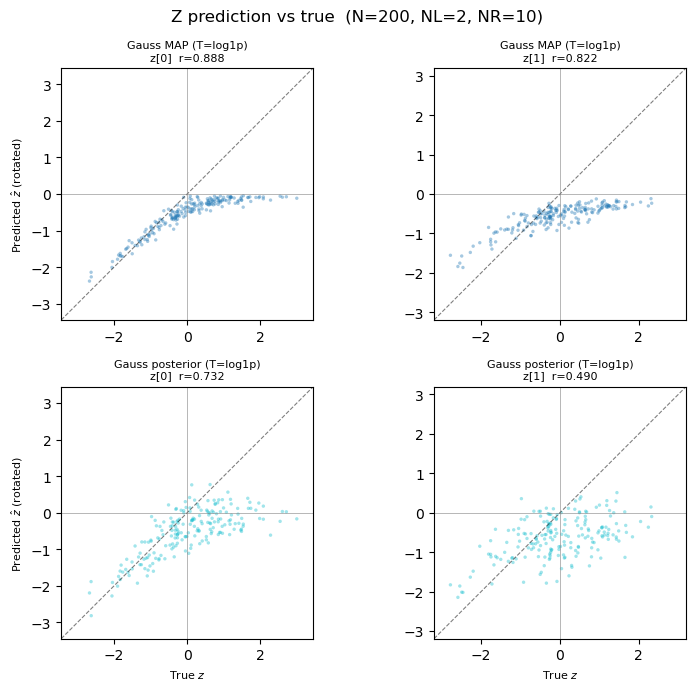

In [4]:

# ── Z prediction: encoder(y) vs true z, per arm ───────────────────────────────
# For each arm: run encoder on all y, rotate z_hat onto z_true, scatter per latent dim.

z_true_np = z_all.cpu().numpy()   # (N, q)  — true latents from simulate()

def _best_rotation_z(Z_true, Z_hat):
    """Procrustes aligning Z_hat columns to Z_true columns (N x q matrices)."""
    # Work on (q x N) x (q x N) cross-covariance: Z_true.T @ Z_hat  is (q x q)
    U, _, Vt = np.linalg.svd(Z_true.T @ Z_hat)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(Z_true - Z_hat @ R1) <= np.linalg.norm(Z_true - Z_hat @ R2) else R2

n_arms    = len(results)
n_cols    = NL          # one column per latent dimension
n_rows    = n_arms

fig_z, axes_z = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 3.5 * n_rows),
                              squeeze=False)
fig_z.suptitle(f"Z prediction vs true  (N={NS}, NL={NL}, NR={NR})", fontsize=12)

for row, (label, (h_err, h_err_ema, h_loss, h_wz, col, enc_type, g_dec)) in enumerate(results.items()):
    enc = encoders[label]
    with torch.no_grad():
        z_hat, _, _ = enc.sample(y_zqe.to(DEV))
    z_hat_np = z_hat.cpu().numpy()   # (N, q)

    R = _best_rotation_z(z_true_np, z_hat_np)
    z_hat_rot = z_hat_np @ R         # (N, q)

    corr_per_dim = [np.corrcoef(z_true_np[:, k], z_hat_rot[:, k])[0, 1] for k in range(NL)]

    for col_idx in range(NL):
        ax = axes_z[row, col_idx]
        ax.scatter(z_true_np[:, col_idx], z_hat_rot[:, col_idx],
                   s=6, alpha=0.4, color=col, edgecolors="none")
        lim = max(np.abs(z_true_np[:, col_idx]).max(),
                  np.abs(z_hat_rot[:, col_idx]).max()) * 1.15
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        r = corr_per_dim[col_idx]
        ax.set_title(f"{label}\nz[{col_idx}]  r={r:.3f}", fontsize=8)
        if row == n_rows - 1: ax.set_xlabel("True $z$", fontsize=8)
        if col_idx == 0:      ax.set_ylabel("Predicted $\\hat{z}$ (rotated)", fontsize=8)

plt.tight_layout()
plt.show()


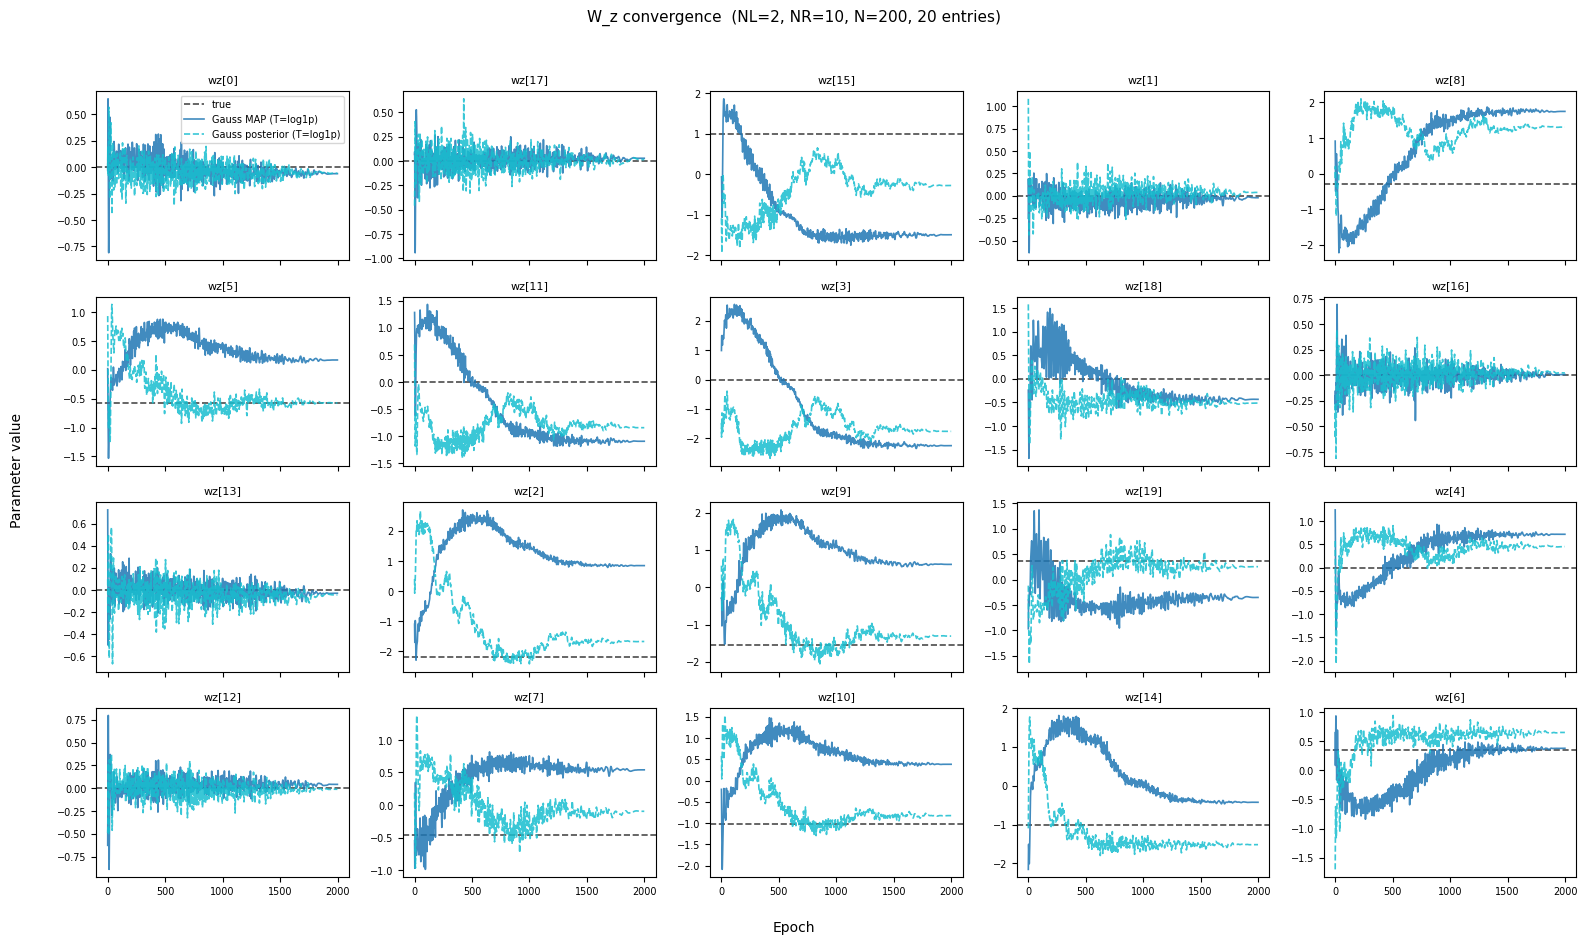

In [5]:

# ── W_z parameter convergence plots ──────────────────────────────────────────
SHOW_ARMS = list(results.keys())   # all arms that actually ran

wz_traj = {lbl: np.array(results[lbl][3]) for lbl in SHOW_ARMS}   # index 3 = h_wz

ncols = min(5, N_WZ_TRACK)
nrows = int(np.ceil(N_WZ_TRACK / ncols))
fig2, axes = plt.subplots(nrows, ncols,
                          figsize=(3.2 * ncols, 2.4 * nrows), sharex=True)
axes = np.array(axes).ravel()
fig2.suptitle(
    f"W_z convergence  (NL={NL}, NR={NR}, N={NS}, {N_WZ_TRACK} entries)",
    fontsize=11,
)

ep_axis = np.arange(EPOCHS_ZQE)
col_arm = {lbl: results[lbl][4] for lbl in SHOW_ARMS}   # index 4 = colour

def _ls_from_label(lbl):
    if "plateau" in lbl: return "-"
    if "poly-0.55" in lbl: return "--"
    if "poly-1.0"  in lbl: return ":"
    # fallback for any other label
    enc_type = results[lbl][5]   # index 5 = enc_type
    return {"map": "-", "gp": "--", "map_id": "-.", "gp_id": ":"}.get(enc_type, "-")

for k, ax in enumerate(axes):
    try:
        if k >= N_WZ_TRACK:
            ax.set_visible(False); continue
        ax.axhline(wz_true[k], color="black", ls="--", lw=1.2, alpha=0.7,
                label="true" if k == 0 else None)
        for lbl in SHOW_ARMS:
            ax.plot(ep_axis, wz_traj[lbl][:, k], color=col_arm[lbl], lw=1.2,
                    ls=_ls_from_label(lbl), label=lbl if k == 0 else None, alpha=0.85)
        ax.set_title(f"wz[{wz_idx[k]}]", fontsize=8)
        ax.tick_params(labelsize=7)
    except:
        pass

axes[0].legend(fontsize=7, loc="upper right")
fig2.text(0.5, 0.02, "Epoch", ha="center", fontsize=10)
fig2.text(0.01, 0.5, "Parameter value", va="center", rotation="vertical", fontsize=10)
plt.tight_layout(rect=[0.03, 0.04, 1, 0.96])
plt.show()


In [6]:

# ── R gllvm benchmark (VA + Laplace) ─────────────────────────────────────────
import subprocess, os, textwrap
import numpy as np
import pandas as pd


RSCRIPT    = "/mnt/c/Program Files/R/R-4.5.1/bin/Rscript.exe"
WIN_TMPDIR = "/mnt/c/Users/willwhite/AppData/Local/Temp/r_gllvm_bench"
os.makedirs(WIN_TMPDIR, exist_ok=True)

def wsl2r(path):
    """Convert /mnt/c/... WSL path to C:/... forward-slash path for R."""
    return path.replace("/mnt/c/", "C:/")

def run_r_gllvm(Y_np, W_true_np, n_latent, method="VA", family="poisson", seed=42):
    y_path = os.path.join(WIN_TMPDIR, "Y.csv")
    w_path = os.path.join(WIN_TMPDIR, "W_hat.csv")
    r_path = os.path.join(WIN_TMPDIR, "run.R")

    if os.path.exists(w_path):
        os.remove(w_path)

    pd.DataFrame(Y_np).to_csv(y_path, index=False, header=False)

    r_method = method if method != "Laplace" else "LA"

    r_code = textwrap.dedent(f"""
        set.seed({seed})
        Y <- as.matrix(read.csv("{wsl2r(y_path)}", header=FALSE))
        suppressPackageStartupMessages(library(gllvm))
        fit <- gllvm(Y, num.lv={n_latent}, family="{family}",
                     method="{r_method}", starting.val="res",
                     control=list(maxit=2000), trace=FALSE)
        # Full loadings = theta %*% diag(sigma.lv)
        # theta is (p x num.lv) with upper-triangle fixed to 0, diagonal to 1;
        # sigma.lv holds the per-LV scale (diagonal of the loading matrix).
        W_full <- sweep(fit$params$theta, 2, fit$params$sigma.lv, "*")
        write.csv(W_full, "{wsl2r(w_path)}", row.names=FALSE)
        cat("converged\\n")
    """)

    with open(r_path, "w") as f:
        f.write(r_code)

    result = subprocess.run(
        [RSCRIPT, "--vanilla", wsl2r(r_path)],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode != 0 or not os.path.exists(w_path):
        print("R stderr:", result.stderr[-1500:])
        return None

    W_hat = pd.read_csv(w_path).values
    U, _, Vt = np.linalg.svd(W_true_np.T @ W_hat)
    R = (U @ Vt).T
    d = np.linalg.norm(W_true_np - W_hat @ R) / np.linalg.norm(W_true_np)
    return float(d), W_hat


# ── Run on the data already in memory from cell 2 ────────────────────────────
Y_train = y_all.cpu().numpy().astype(int)
W_true  = g0m.wz.detach().cpu().numpy()

print(f"Data: N={Y_train.shape[0]}, p={Y_train.shape[1]}, q={NL}")

print("Fitting R gllvm (VA) ...")
_r_va  = run_r_gllvm(Y_train, W_true, n_latent=NL, method="VA")
err_r_va,  wz_r_va  = _r_va  if _r_va  is not None else (None, None)
print(f"  R gllvm VA    Procrustes = {err_r_va:.4f}" if err_r_va is not None else "  VA failed")

print("Fitting R gllvm (LA) ...")
_r_lap = run_r_gllvm(Y_train, W_true, n_latent=NL, method="LA")
err_r_lap, wz_r_lap = _r_lap if _r_lap is not None else (None, None)
print(f"  R gllvm LA    Procrustes = {err_r_lap:.4f}" if err_r_lap is not None else "  LA failed")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"{'Method':<30} {'Procrustes':>10}")
print(f"{'─'*45}")
print(f"{'VAE':<30} {err_vae_m:>10.4f}")
for label, vals in results.items():
    print(f"{label:<30} {vals[0][-1]:>10.4f}")
if err_r_va  is not None: print(f"{'R gllvm (VA)':<30} {err_r_va:>10.4f}")
if err_r_lap is not None: print(f"{'R gllvm (LA)':<30} {err_r_lap:>10.4f}")

print(f"{'─'*45}")

Data: N=200, p=10, q=2
Fitting R gllvm (VA) ...
  R gllvm VA    Procrustes = 0.1404
Fitting R gllvm (LA) ...
  R gllvm LA    Procrustes = 0.1638

─────────────────────────────────────────────
Method                         Procrustes
─────────────────────────────────────────────
VAE                                0.2105
Gauss MAP (T=log1p)                0.1790
Gauss posterior (T=log1p)          0.1829
R gllvm (VA)                       0.1404
R gllvm (LA)                       0.1638
─────────────────────────────────────────────


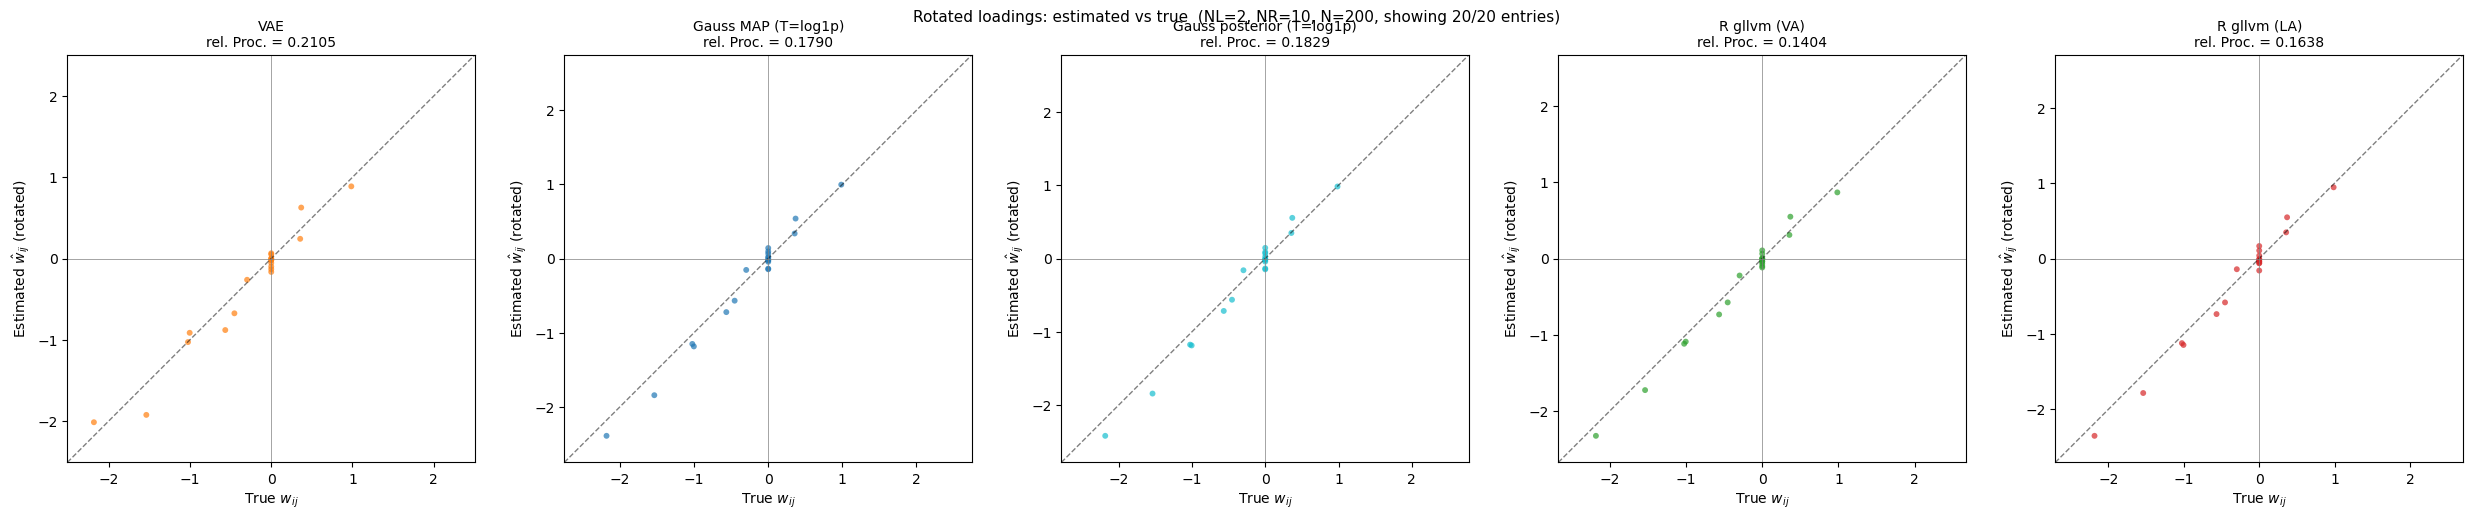

In [7]:

# ── Rotated loadings: estimated vs true (visual Procrustes check) ─────────────
MAX_SHOW = 100

def aligned_wz(W_true, W_hat):
    R = _best_rotation(W_true, W_hat)
    return W_hat @ R

W_true_np = g0m.wz.detach().cpu().numpy()   # (p, q)

# Collect all methods: VAE, ZQE arms, R baselines
_method_wz = {"VAE": (g_vae_m.wz.detach().cpu().numpy(), "tab:orange")}
for lbl, (h_err, h_err_ema, h_loss, h_wz, col, enc_type, g_dec) in results.items():
    _method_wz[lbl] = (g_dec.wz.detach().cpu().numpy(), col)
if wz_r_va  is not None: _method_wz["R gllvm (VA)"]  = (wz_r_va,  "tab:green")
if wz_r_lap is not None: _method_wz["R gllvm (LA)"]  = (wz_r_lap, "tab:red")

n_methods = len(_method_wz)
fig4, axes4 = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5))
if n_methods == 1:
    axes4 = [axes4]

p, q = W_true_np.shape
n_entries = p * q
idx_show  = np.random.choice(n_entries, min(MAX_SHOW, n_entries), replace=False)
w_true_flat = W_true_np.ravel()

for ax, (method, (W_hat, col)) in zip(axes4, _method_wz.items()):
    W_aligned  = aligned_wz(W_true_np, W_hat)
    x = w_true_flat[idx_show]
    y = W_aligned.ravel()[idx_show]
    err = np.linalg.norm(W_true_np - W_aligned) / np.linalg.norm(W_true_np)
    ax.scatter(x, y, s=18, alpha=0.7, color=col, edgecolors="none")
    lim = max(np.abs(x).max(), np.abs(y).max()) * 1.15
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1.0, alpha=0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("True $w_{ij}$")
    ax.set_ylabel("Estimated $\\hat{w}_{ij}$ (rotated)")
    ax.set_title(f"{method}\nrel. Proc. = {err:.4f}", fontsize=10)
    ax.set_aspect("equal")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)

fig4.suptitle(
    f"Rotated loadings: estimated vs true  "
    f"(NL={NL}, NR={NR}, N={NS}, showing {min(MAX_SHOW, n_entries)}/{n_entries} entries)",
    fontsize=11,
)
plt.tight_layout(); plt.show()
